<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/04_learning_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### 4 - Learning Curves
**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

This notebook, contains the visualizations regarding the project, mainly the learning curves but also smaller plots to support the report.

**Observation:** The first cell of code bellow was implemente to be able to run the notebook using Google Colab, while the rest o the code was initially wroten using DataSpell.

In [1]:
!rm -rf /content/TOL506M_Final_Project

In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# Always clone fresh in Colab
subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

In [3]:
import sys
import os
import subprocess
import importlib
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch

project_root = Path.cwd()
if project_root.name != "TOL506M_Final_Project":
    original = project_root
    while project_root.name != "TOL506M_Final_Project" and project_root != project_root.parent:
        project_root = project_root.parent

    if project_root.name == "TOL506M_Final_Project":
        os.chdir(project_root)
        print(f"Changed working directory from {original} to {project_root}")
    else:
        raise RuntimeError(
            "Could not locate the TOL506M_Final_Project root directory. "
            "Please run this notebook/script from within the project tree."
        )
else:
    print(f"Working directory: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 8), "font.size": 12})

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Working directory: /content/TOL506M_Final_Project

PyTorch version: 2.9.0+cu126
CUDA available: True


In [4]:
# Import project modules
from config import Config
from utils.visualization import plot_learning_curve_for_metric

# Create output dirs if they don't exist
Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
Config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
Config.METRICS_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
# =========================================================
# Helpers - Loaders and Calculaters
# =========================================================

def load_summaries(filepaths):
    """
    filepaths: list of paths to JSON files.
    Returns: list of lists of result dicts.
    """
    all_runs = []
    for fp in filepaths:
        with open(fp, "r") as f:
            all_runs.append(json.load(f))
    return all_runs

def mean_and_sigma(values):
    """
    values: list of floats.
    Returns: (mean, uncertainty) where uncertainty is
    the sample standard deviation (ddof=1).
    """
    if not values:
        return np.nan, np.nan
    if len(values) == 1:
        return float(values[0]), 0.0
    arr = np.array(values, dtype=float)
    mean = float(arr.mean())
    sigma = float(arr.std(ddof=1))
    return mean, sigma

def extract_time_seconds(rec):
    """
    Robustly extract a time in seconds from a record.
    Tries training_time / training_times / inference_time / inference_times.
    Returns float or None.
    """
    for key in ["training_time", "training_times", "inference_time", "inference_times"]:
        if key in rec:
            return float(rec[key])
    return None

def extract_metrics(rec):
    """
    Extract accuracy / precision / recall / f1 from a record.
    Can be flat or nested under 'test_metrics'.
    Returns dict with keys: accuracy, precision, recall, f1.
    """
    metrics = rec.get("test_metrics", rec)

    acc = metrics.get("accuracy", np.nan)
    prec = metrics.get("precision", np.nan)
    rec_ = metrics.get("recall", np.nan)
    if "f1" in metrics:
        f1 = metrics["f1"]
    else:
        f1 = metrics.get("f1_score", np.nan)

    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec_),
        "f1": float(f1),
    }

# =========================================================
# Results Loaders
# =========================================================

task1_files = [
    "/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary.json",
    "/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary_42.json",
    "/content/TOL506M_Final_Project/results/metrics/task1_scratch_all_fractions_summary_640.json",
]

task2_files = [
    "/content/TOL506M_Final_Project/results/metrics/task2_finetune_summary.json",
    "/content/TOL506M_Final_Project/results/metrics/task2_finetune_summary_42.json",
    "/content/TOL506M_Final_Project/results/metrics/task2_finetune_summary_640.json",
]
task3_files = [
    "/content/TOL506M_Final_Project/results/metrics/task3_zeroshot.json",
    "/content/TOL506M_Final_Project/results/metrics/task3_zeroshot2.json",
    "/content/TOL506M_Final_Project/results/metrics/task3_zeroshot_3.json",
]

# Load all runs
task1_runs = load_summaries(task1_files)
task2_runs = load_summaries(task2_files)
task3_runs = load_summaries(task3_files)

# =========================================================
# Aggregate per data fraction
# =========================================================

rows = []
all_fractions = set()

# Task 1: Scratch
scratch_agg = defaultdict(lambda: defaultdict(list))

for run in task1_runs:
    for rec in run:
        frac = rec.get("data_fraction")
        if frac is None:
            continue
        all_fractions.add(frac)

        t = extract_time_seconds(rec)
        metrics = extract_metrics(rec)

        if t is not None:
            scratch_agg[frac]["time"].append(t)
        scratch_agg[frac]["accuracy"].append(metrics["accuracy"])
        scratch_agg[frac]["precision"].append(metrics["precision"])
        scratch_agg[frac]["recall"].append(metrics["recall"])
        scratch_agg[frac]["f1"].append(metrics["f1"])

for frac, m in scratch_agg.items():
    time_mean, time_unc = mean_and_sigma(m["time"]) if "time" in m else (np.nan, np.nan)
    acc_mean, acc_unc = mean_and_sigma(m["accuracy"])
    prec_mean, prec_unc = mean_and_sigma(m["precision"])
    rec_mean, rec_unc = mean_and_sigma(m["recall"])
    f1_mean, f1_unc = mean_and_sigma(m["f1"])

    rows.append({
        "Method": "Task 1 (scratch)",
        "data_fraction": frac,
        "time": time_mean / 60.0 if not np.isnan(time_mean) else np.nan,
        "time uncertainty": time_unc / 60.0 if not np.isnan(time_unc) else np.nan,
        "accuracy": acc_mean,
        "accuracy uncertainty": acc_unc,
        "precision": prec_mean,
        "precision uncertainty": prec_unc,
        "recall": rec_mean,
        "recall uncertainty": rec_unc,
        "f1-score": f1_mean,
        "f1-score uncertainty": f1_unc,
    })

# Task 2: Fine-tune broken into the 4 modes
freeze_layers = Config.FREEZE_LAYERS

# finetune_agg[mode][frac] -> metric_name -> [values]
finetune_agg = {
    mode: defaultdict(lambda: defaultdict(list)) for mode in freeze_layers
}

for run in task2_runs:
    for rec in run:
        freeze = rec.get("hyperparameters", {}).get("freeze_layers", None)
        if freeze not in freeze_layers:
            continue

        frac = rec.get("data_fraction")
        if frac is None:
            continue

        all_fractions.add(frac)

        t = extract_time_seconds(rec)
        metrics = extract_metrics(rec)

        if t is not None:
            finetune_agg[freeze][frac]["time"].append(t)
        finetune_agg[freeze][frac]["accuracy"].append(metrics["accuracy"])
        finetune_agg[freeze][frac]["precision"].append(metrics["precision"])
        finetune_agg[freeze][frac]["recall"].append(metrics["recall"])
        finetune_agg[freeze][frac]["f1"].append(metrics["f1"])

# Turn aggregates into rows: one row per (mode, data_fraction)
for mode, frac_dict in finetune_agg.items():
    for frac, m in frac_dict.items():
        time_mean, time_unc = mean_and_sigma(m["time"]) if "time" in m else (np.nan, np.nan)
        acc_mean, acc_unc = mean_and_sigma(m["accuracy"])
        prec_mean, prec_unc = mean_and_sigma(m["precision"])
        rec_mean, rec_unc = mean_and_sigma(m["recall"])
        f1_mean, f1_unc = mean_and_sigma(m["f1"])

        rows.append({
            "Method": f"Task 2 (freeze={mode})",
            "data_fraction": frac,
            "time": time_mean / 60.0 if not np.isnan(time_mean) else np.nan,
            "time uncertainty": time_unc / 60.0 if not np.isnan(time_unc) else np.nan,
            "accuracy": acc_mean,
            "accuracy uncertainty": acc_unc,
            "precision": prec_mean,
            "precision uncertainty": prec_unc,
            "recall": rec_mean,
            "recall uncertainty": rec_unc,
            "f1-score": f1_mean,
            "f1-score uncertainty": f1_unc,
        })

# Task 3: Linear probe
linear_probe_times = []
linear_probe_accs = []
linear_probe_precs = []
linear_probe_recs = []
linear_probe_f1s = []

for run in task3_runs:
    lp = run.get("linear_probe")
    if lp is None:
        continue

    t = extract_time_seconds(lp)
    metrics = extract_metrics(lp)

    if t is not None:
        linear_probe_times.append(t)
    linear_probe_accs.append(metrics["accuracy"])
    linear_probe_precs.append(metrics["precision"])
    linear_probe_recs.append(metrics["recall"])
    linear_probe_f1s.append(metrics["f1"])

time_mean, time_unc = mean_and_sigma(linear_probe_times) if linear_probe_times else (np.nan, np.nan)
acc_mean, acc_unc = mean_and_sigma(linear_probe_accs)
prec_mean, prec_unc = mean_and_sigma(linear_probe_precs)
rec_mean, rec_unc = mean_and_sigma(linear_probe_recs)
f1_mean, f1_unc = mean_and_sigma(linear_probe_f1s)

# Same metrics replicated for all fractions
for frac in sorted(all_fractions):
    rows.append({
        "Method": "linear probe",
        "data_fraction": frac,
        "time": time_mean / 60.0 if not np.isnan(time_mean) else np.nan,
        "time uncertainty": time_unc / 60.0 if not np.isnan(time_unc) else np.nan,
        "accuracy": acc_mean,
        "accuracy uncertainty": acc_unc,
        "precision": prec_mean,
        "precision uncertainty": prec_unc,
        "recall": rec_mean,
        "recall uncertainty": rec_unc,
        "f1-score": f1_mean,
        "f1-score uncertainty": f1_unc,
    })

# Task 3: Zero-shot -> constant across fractions
zero_times = []
zero_accs = []
zero_precs = []
zero_recs = []
zero_f1s = []

for run in task3_runs:
    zs = run.get("zero_shot")
    if zs is None:
        continue

    t = extract_time_seconds(zs)
    metrics = extract_metrics(zs)

    if t is not None:
        zero_times.append(t)
    zero_accs.append(metrics["accuracy"])
    zero_precs.append(metrics["precision"])
    zero_recs.append(metrics["recall"])
    zero_f1s.append(metrics["f1"])

time_mean, time_unc = mean_and_sigma(zero_times) if zero_times else (np.nan, np.nan)
acc_mean, acc_unc = mean_and_sigma(zero_accs)
prec_mean, prec_unc = mean_and_sigma(zero_precs)
rec_mean, rec_unc = mean_and_sigma(zero_recs)
f1_mean, f1_unc = mean_and_sigma(zero_f1s)

# Same metrics replicated for all fractions
for frac in sorted(all_fractions):
    rows.append({
        "Method": "Task 3 (zero shot)",
        "data_fraction": frac,
        "time": time_mean / 60.0 if not np.isnan(time_mean) else np.nan,
        "time uncertainty": time_unc / 60.0 if not np.isnan(time_unc) else np.nan,
        "accuracy": acc_mean,
        "accuracy uncertainty": acc_unc,
        "precision": prec_mean,
        "precision uncertainty": prec_unc,
        "recall": rec_mean,
        "recall uncertainty": rec_unc,
        "f1-score": f1_mean,
        "f1-score uncertainty": f1_unc,
    })

# =========================================================
# Combaine into a Data frame
# =========================================================

df = pd.DataFrame(rows, columns=[
    "Method",
    "data_fraction",
    "time",
    "time uncertainty",
    "accuracy",
    "accuracy uncertainty",
    "precision",
    "precision uncertainty",
    "recall",
    "recall uncertainty",
    "f1-score",
    "f1-score uncertainty",
])

df = df.sort_values(["data_fraction", "Method"]).reset_index(drop=True)
df

,Method,data_fraction,time,time uncertainty,accuracy,accuracy uncertainty,precision,precision uncertainty,recall,recall uncertainty,f1-score,f1-score uncertainty
0,Task 1 (scratch),0.10,21.265638,6.643188,54.511502,7.609326,56.783760,4.039087,54.511502,7.609326,53.060811,8.790706
1,Task 2 (freeze=all_but_fc),0.10,11.278724,1.825044,93.608352,0.522493,93.782091,0.446258,93.608352,0.522493,93.589289,0.529561
2,Task 2 (freeze=up_to_layer1),0.10,15.721715,1.291436,89.432136,0.576764,89.537856,0.480068,89.432136,0.576764,89.381048,0.597256
3,Task 2 (freeze=up_to_layer2),0.10,12.274564,7.456482,88.846448,3.551120,89.270001,2.962473,88.846448,3.551120,88.837753,3.525085
4,Task 2 (freeze=up_to_layer3),0.10,15.504779,0.888665,93.082081,0.424073,93.137486,0.437877,93.082081,0.424073,93.069590,0.423712
5,Task 3 (zero shot),0.10,0.883674,0.281231,18.122400,0.347604,8.968869,2.852154,18.122400,0.347604,8.139171,0.093875
6,linear probe,0.10,0.301896,0.176324,99.210593,0.088212,99.212511,0.088826,99.210593,0.088212,99.209367,0.088481
7,Task 1 (scratch),0.25,44.123553,11.634633,74.586198,2.110810,74.867109,2.168937,74.586198,2.110810,74.523406,2.111486
8,Task 2 (freeze=all_but_fc),0.25,20.362527,7.886529,94.822171,0.421773,94.859707,0.393391,94.822171,0.421773,94.809285,0.427095
9,Task 2 (freeze=up_to_layer1),0.25,21.995586,9.882638,90.671420,2.464209,90.888747,2.179015,90.671420,2.464209,90.584203,2.552494


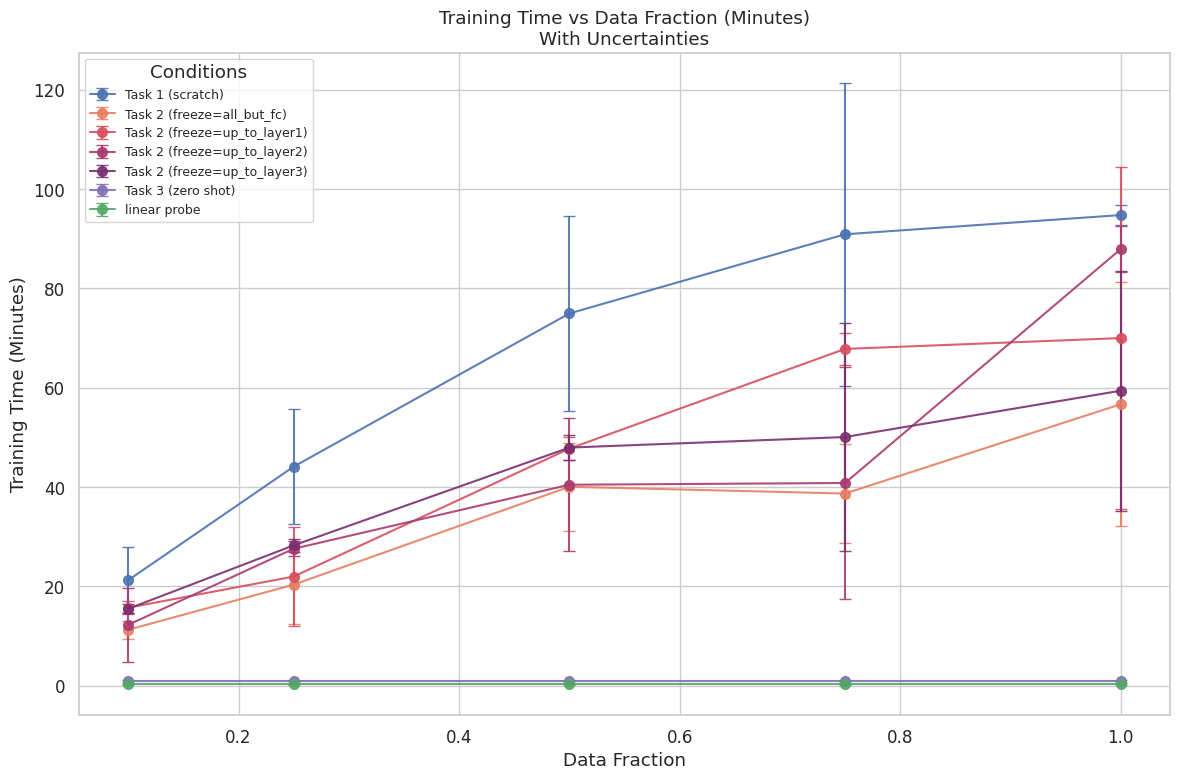

In [6]:
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(12, 8))

# Define consistent base palette
palette = {
    "Task 1 (scratch)": "C0",
    "Task 3 (zero shot)": "C4",
    "linear probe": "C2",
}

# Identify Task 2 methods (everything that's not T1, T3, or linear probe)
task2_methods = [
    method for method in df["Method"].unique()
    if method not in ["Task 1 (scratch)", "Task 3 (zero shot)", "linear probe"]
]

# Palette for Task 2 freezing-layer modes
flare_pal = sns.color_palette("flare", n_colors=len(task2_methods))
for method, color in zip(task2_methods, flare_pal):
    palette[method] = color

# Plot with error bars
for method, subset in df.groupby("Method"):
    # symmetric errors from "time uncertainty"
    yerr = subset["time uncertainty"].values

    plt.errorbar(
        subset["data_fraction"],
        subset["time"],
        yerr=yerr,
        fmt="o-",
        markersize=7,
        capsize=4,
        label=method,
        color=palette.get(method, "C7"),
        alpha=0.9,
    )

plt.title("Training Time vs Data Fraction (Minutes)\nWith Uncertainties")
plt.xlabel("Data Fraction")
plt.ylabel("Training Time (Minutes)")
plt.legend(title="Conditions", fontsize=9)
plt.tight_layout()
plt.savefig("results/plots/training_times_plot.png", dpi=600, bbox_inches="tight")
plt.show()

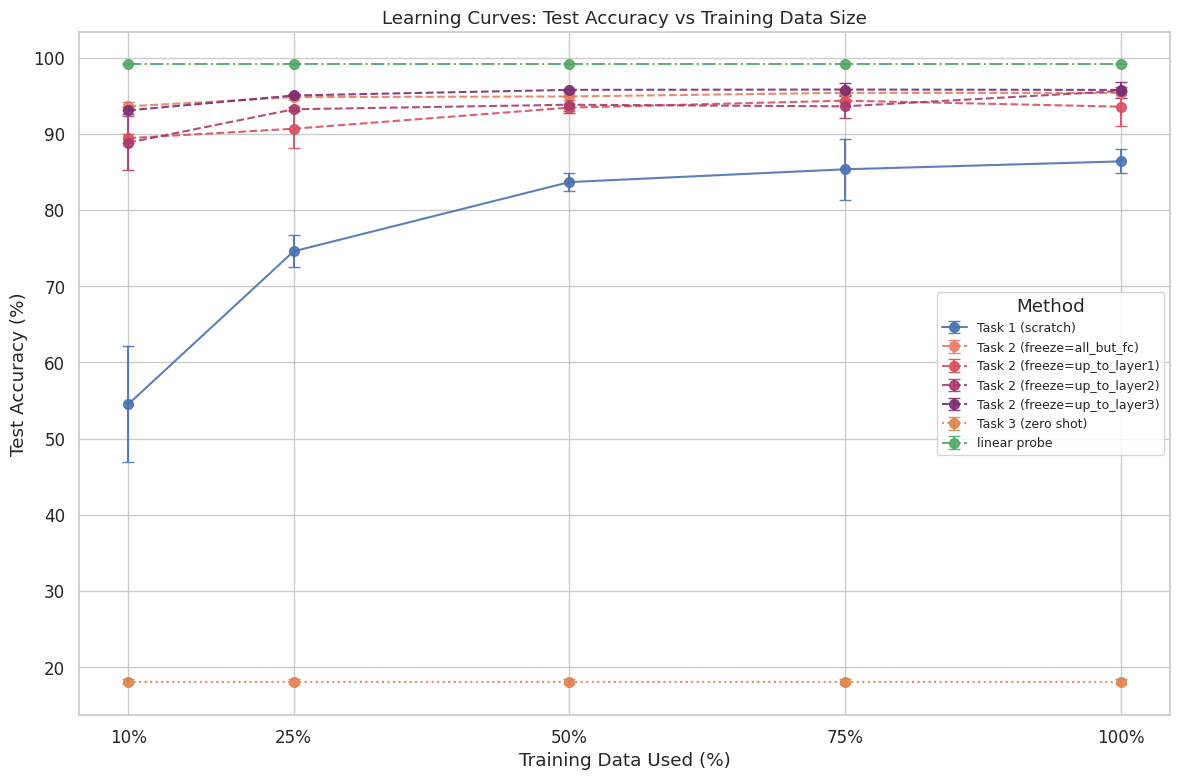

In [7]:
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(12, 8))

# -------------------------------------------------
# Set up palettes
# -------------------------------------------------
base_palette = {
    "Task 1 (scratch)": "C0",       # from-scratch CNN
    "Task 3 (zero shot)": "C1",     # zero-shot SigLIP 2 baseline
    "linear probe": "C2",           # logistic-regression / linear probe
}

# All fine-tuning variants (Task 2)
finetune_methods = [
    m for m in df["Method"].unique()
    if m.startswith("Task 2")
]

# Give each fine-tuning mode its own color
flare_pal = sns.color_palette("flare", n_colors=len(finetune_methods))
for method, color in zip(finetune_methods, flare_pal):
    base_palette[method] = color


def plot_method(method, style="-", zorder=None):
    subset = df[df["Method"] == method].sort_values("data_fraction")
    if subset.empty:
        return

    # X: training data fraction in percentages
    x = subset["data_fraction"].values * 100.0
    y = subset["accuracy"].values
    yerr = subset["accuracy uncertainty"].values

    plt.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle=style,
        capsize=4,
        markersize=7,
        label=method,
        color=base_palette.get(method, None),
        alpha=0.9,
        zorder=zorder,
    )

# ====================================================
# Plot each method
# ====================================================

# Training from scratch
plot_method("Task 1 (scratch)", style="-", zorder=5)

# All fine-tuning freezing strategies (Task 2)
for m in finetune_methods:
    plot_method(m, style="--")

# Zero-shot baseline
plot_method("Task 3 (zero shot)", style=":", zorder=6)

# Linear probe on SigLIP2 embeddings
plot_method("linear probe", style="-.", zorder=7)

plt.title("Learning Curves: Test Accuracy vs Training Data Size")
plt.xlabel("Training Data Used (%)")
plt.ylabel("Test Accuracy (%)")

fractions = np.sort(df["data_fraction"].unique())
plt.xticks(fractions * 100.0, [f"{int(f * 100)}%" for f in fractions])

plt.legend(title="Method", fontsize=9)
plt.tight_layout()
plt.savefig("results/plots/learning_curves_accuracy.png", dpi=600, bbox_inches="tight")
plt.show()

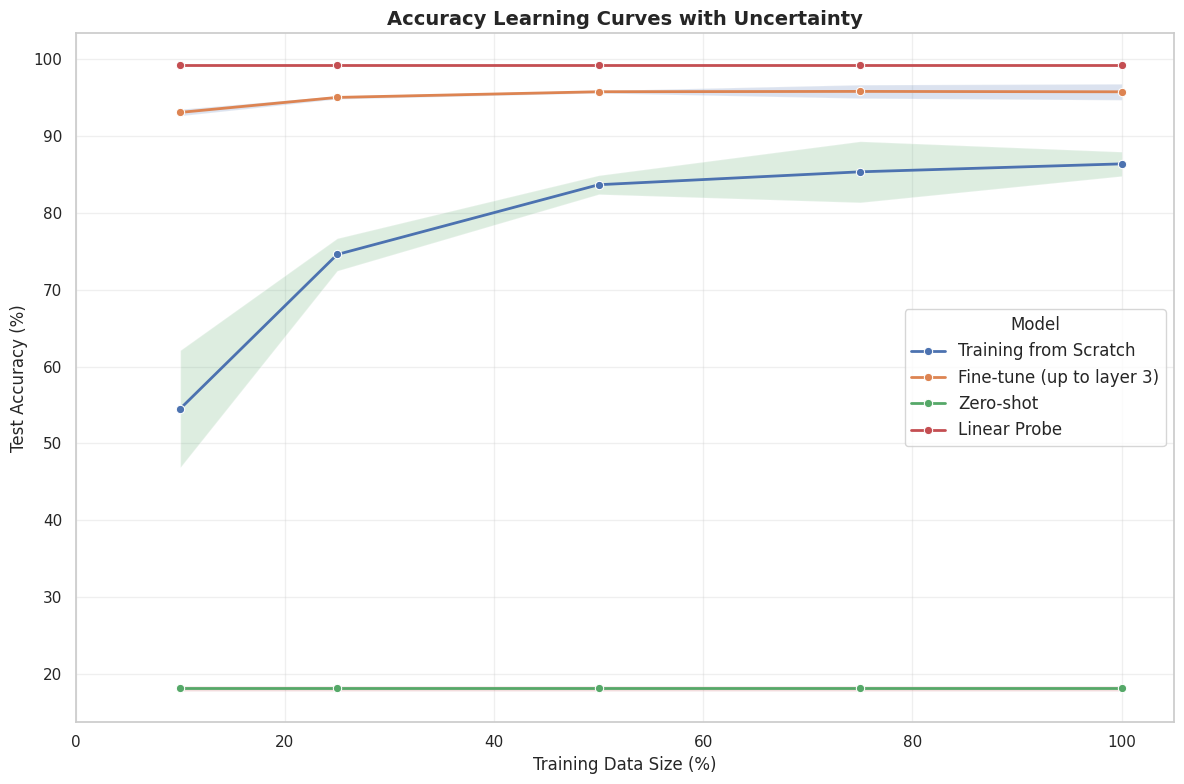

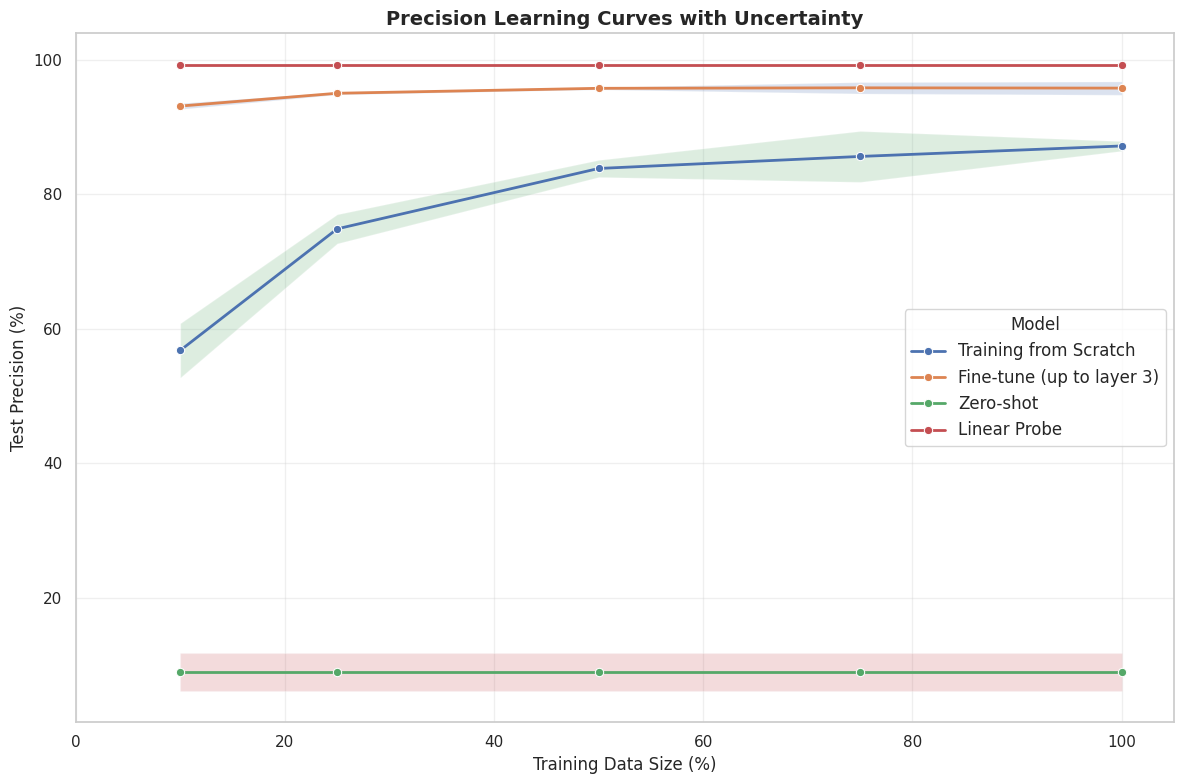

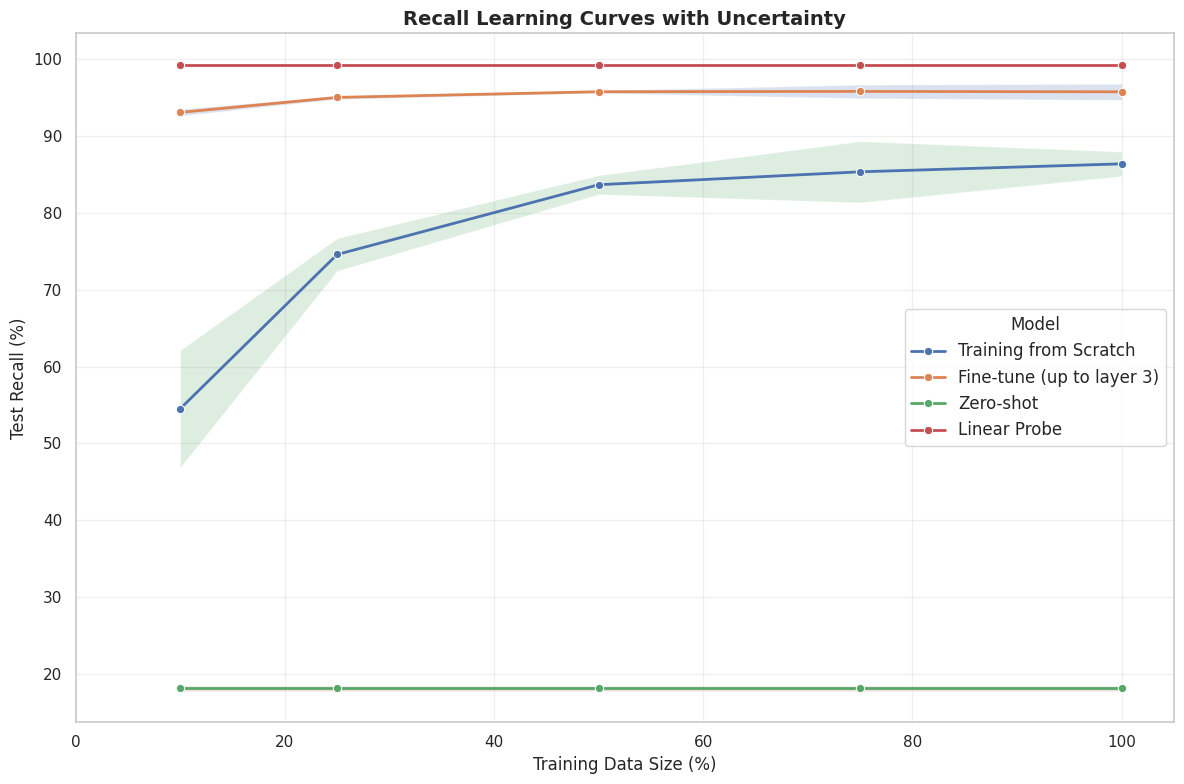

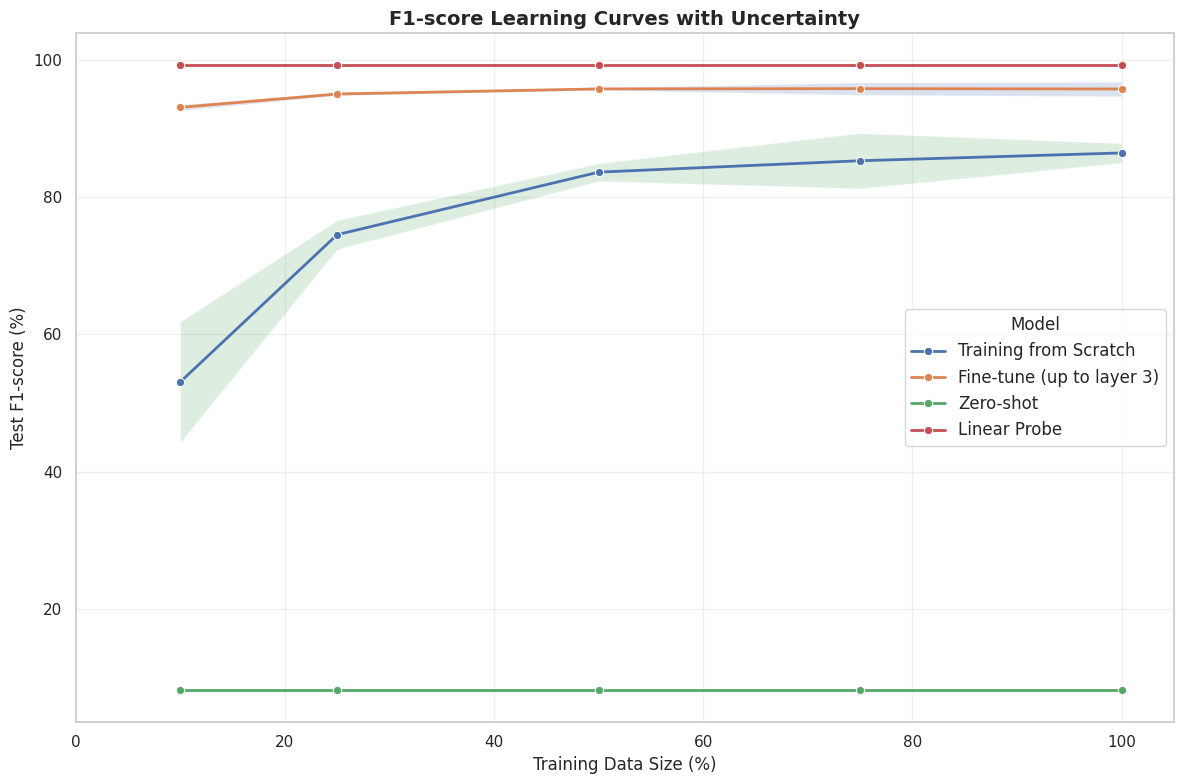

In [8]:
# Methods we care about
methods_to_use = [
    "Task 1 (scratch)",
    "Task 2 (freeze=up_to_layer3)",
    "Task 3 (zero shot)",
    "linear probe"
]

method_name_map = {
    "Task 1 (scratch)": "Training from Scratch",
    "Task 2 (freeze=up_to_layer3)": "Fine-tune (up to layer 3)",
    "Task 3 (zero shot)": "Zero-shot",
    "linear probe": "Linear Probe"
}

plot_learning_curve_for_metric(
    df,
    metric_col="accuracy",
    metric_unc_col="accuracy uncertainty",
    metric_pretty_name="Accuracy",
    methods_to_use = methods_to_use,
    method_name_map = method_name_map
)

plot_learning_curve_for_metric(
    df,
    metric_col="precision",
    metric_unc_col="precision uncertainty",
    metric_pretty_name="Precision",
    methods_to_use = methods_to_use,
    method_name_map = method_name_map
)

plot_learning_curve_for_metric(
    df,
    metric_col="recall",
    metric_unc_col="recall uncertainty",
    metric_pretty_name="Recall",
    methods_to_use = methods_to_use,
    method_name_map = method_name_map
)

plot_learning_curve_for_metric(
    df,
    metric_col="f1-score",
    metric_unc_col="f1-score uncertainty",
    metric_pretty_name="F1-score",
    methods_to_use = methods_to_use,
    method_name_map = method_name_map
)

In [9]:
# Filter only the runs trained on the full dataset (data_fraction = 1.00)
df_full = df[df["data_fraction"] == 1.00].copy()

# Select the relevant columns
cols = [
    "Method",
    "accuracy", "accuracy uncertainty",
    "precision", "precision uncertainty",
    "recall", "recall uncertainty",
    "f1-score", "f1-score uncertainty"
]

results_table = df_full[cols].reset_index(drop=True)

# Pretty formatting (optional): combine value ± uncertainty
def combine(value, unc):
    return f"{value:.3f} ± {unc:.3f}"

results_table["Accuracy"] = results_table.apply(
    lambda r: combine(r["accuracy"], r["accuracy uncertainty"]), axis=1)
results_table["Precision"] = results_table.apply(
    lambda r: combine(r["precision"], r["precision uncertainty"]), axis=1)
results_table["Recall"] = results_table.apply(
    lambda r: combine(r["recall"], r["recall uncertainty"]), axis=1)
results_table["F1-score"] = results_table.apply(
    lambda r: combine(r["f1-score"], r["f1-score uncertainty"]), axis=1)

# Keep only clean columns for display
final_table = results_table[["Method", "Accuracy", "Precision", "Recall", "F1-score"]]

print(final_table.to_string(index=False))

                      Method       Accuracy      Precision         Recall       F1-score
            Task 1 (scratch) 86.385 ± 1.583 87.203 ± 0.726 86.385 ± 1.583 86.432 ± 1.408
  Task 2 (freeze=all_but_fc) 95.357 ± 0.322 95.395 ± 0.318 95.357 ± 0.322 95.348 ± 0.317
Task 2 (freeze=up_to_layer1) 93.566 ± 2.588 93.724 ± 2.328 93.566 ± 2.588 93.559 ± 2.585
Task 2 (freeze=up_to_layer2) 95.620 ± 0.153 95.631 ± 0.146 95.620 ± 0.153 95.614 ± 0.151
Task 2 (freeze=up_to_layer3) 95.764 ± 1.045 95.810 ± 0.993 95.764 ± 1.045 95.752 ± 1.054
          Task 3 (zero shot) 18.122 ± 0.348  8.969 ± 2.852 18.122 ± 0.348  8.139 ± 0.094
                linear probe 99.211 ± 0.088 99.213 ± 0.089 99.211 ± 0.088 99.209 ± 0.088
